## Exercise III: Monte Carlo Simulation and Confidence Intervals [Total:30]

Let $U$ be uniformly distributed on $[0,1]$. You have to use Monte Carlo simulation to estimate the value of:
\begin{equation}
    \bar{f} = \mathbb{E}[f(U)],
\end{equation}
where $f(x)=x \cos(\pi x)$.



1.   Calculate analytically the exact value for $\bar{f}$ and $σ^2=\mathbb{E}[(f(U)-\bar{f})^2]$; show all the steps. **[5 Marks]**
2.   Write a Python function which computes
\begin{equation}
    Y_m = \frac{1}{N}\sum_{n=1}^{N} f(U^{(m,n)})
\end{equation}
for $1000$ different sets of $1000$ independent random variables $U^{(m,n)}$. **[5 Marks]**
3. Sort the $Y_m$ into ascending order, and then plot $C_m = (m-1/2)/1000$ versus $Y_m$ - this is the numerical cumulative distribution function. Superimpose on the same plot the cumulative distribution function you
would expect from the Central Limit Theorem and comment on your results. You may like to experiment by trying larger or smaller sets of points to
improve your understanding of the asymptotic behaviour described by
the CLT. **[6 Marks]**

4. Modify your code to use a single set of $10^{6}$ random numbers, and plot
\begin{equation}
    Y_{N} = N^{-1} \sum_{n=1}^{N} f(U^{(n)})
\end{equation}

versus $N$ for $N = 10^{3} - 10^{6}$.  This should demonstrate the convergence to the true value predicted by the Strong Law of Large Numbers. For each $N$, also compute an unbiased estimate for the variance $\sigma^2$ and hence add to the plot upper and lower confidence bounds based on 3 standard deviations of the variation in the mean. Add a line corresponding to the true value. Does this lie inside the bounds?**[6 Marks]**

5. Repeat points 1-4 for a European Call option in which the final value of the underlying is

\begin{equation}
    S(T) = S(0) \exp\left((r-\frac{1}{2}\sigma^2)T + \sigma W(T)\right)
\end{equation}

where $W(T)=\sqrt{T} X = \sqrt{T} Φ^{-1}(U)$, with $X$ being a unit Normal or $U$ a uniform $(0, 1)$ random variable. The payoff function is $f(s) = \exp(-r T)(S(T)-K)^{+}$ and the constants are $r = 0.05, \sigma=0.2, S(0)=100, K=100$.

There is no need to compute the analytic variance in part 1.; just use the
unbiased estimator when plotting the CLT prediction in part 4. The code for computing the price of the European Call option is provided here below.**[8 Marks]**


# 3.1

$$
E(f(x))=\int_0^1f(x) dx=\int_0^1x cos(\pi x) dx
$$

To integrate this, I will use integration by parts where $u=x$ and $dv=cos(\pi x)dx$ where
$$
\int_0^1udv = [uv]_0^1- \int_0^1vdu
$$
So $du=dx$ and $v=\frac{1}{\pi}sin(\pi x)$

Hence, we get:
$$
\int_0^1x cos(\pi x) dx = [x\frac{1}{\pi}sin(\pi x)]_0^1- \int_0^1 \frac{1}{\pi} sin(\pi x)  dx
$$

The first part: $[x\frac{1}{\pi}sin(\pi x)]_0^1= 0-0=0$

The second part: $$- \int_0^1 \frac{1}{\pi} sin(\pi x)  dx \\= [\frac{1}{\pi^2}cos(\pi x)]^1_0\\= \frac{1}{\pi^2}[-1-1]= \frac{-2}{\pi^2}\approx -0.202642$$

We will now find the variance
$$
\mathbb{E}\big[(f(u)-\bar f)^2\big] 
= \mathbb{E}(f^2) - \mathbb{E}(f)^2 \\
= \mathbb{E}(f^2) - \left(\frac{2}{\pi^2}\right)^2
$$

$$
f(x) = x\cos(\pi x)
$$

\begin{align}
\mathbb{E}(f^2)
&= \int_0^1 x^2\cos^2(\pi x)\,dx
\end{align}

Using the identity

$$
\cos^2(\pi x) = \frac{1+\cos(2\pi x)}{2}
$$

\begin{align}
\int_0^1 x^2\cos^2(\pi x)\,dx
&= \int_0^1 x^2 \frac{1+\cos(2\pi x)}{2}\,dx \\
&= \frac{1}{2}\int_0^1 x^2\,dx + \frac{1}{2}\int_0^1 x^2\cos(2\pi x)\,dx
\end{align}

\begin{align}
\frac{1}{2}\int_0^1 x^2\,dx
&= \frac{1}{2}\left[\frac{x^3}{3}\right]_0^1 \\
&= \frac{1}{6}
\end{align}


For the second term use **integration by parts**

$$
u = x^2, \qquad dv = \cos(2\pi x)\,dx
$$

Then

$$
v = \frac{1}{2\pi} sin(2\pi x)\\
du = 2xdx 
$$

So

$$
\int_0^1 x^2\cos(2\pi x)\,du
= \Big[uv\Big]_0^1 - \int_0^1 v\,dx \\
= [x^2 \frac{1}{2\pi} sin(2\pi x)]_0^1 - \int_0^1 \frac{1}{2\pi} sin(2\pi x)2xdx
$$
for $[x^2 \frac{1}{2\pi} sin(2\pi x)]_0^1=0-0=0$

While for $$- \frac{1}{\pi} \int_0^1  sin(2\pi x)xdx $$ 
we use integration by parts one final time where $u=x$ and $dv=sin(2\pi x)$, so $du=dx$ and $v= -\frac{1}{2 \pi}cos(2\pi x)$

$$ \int_0^1  sin(2\pi x)xdx
= \Big[uv\Big]_0^1 - \int_0^1 v\,dx \\
= [-x \frac{1}{2 \pi}cos(2\pi x)]_0^1 + \int_0^1 \frac{1}{2 \pi}cos(2\pi x)dx \\
= -\frac{1}{2 \pi} + [\frac{1}{(2 \pi)^2}sin(2\pi x)]^1_0 \\
= -\frac{1}{2 \pi} + [\frac{1}{(2 \pi)^2}sin(2\pi x)]^1_0 \\
= -\frac{1}{2 \pi} 
$$
So we get that
$$
-\frac{1}{\pi}\int_0^1  sin(2\pi x)xdx = \frac{1}{2 \pi^2} 
$$

Which again gives us
$\frac{1}{2}\int_0^1 x^2\cos(2\pi x)\,dx= -\frac{1}{4\pi}$

We finally combine everything, which gives us

$$
\mathbb{E}(f^2) = \int_0^1 x^2\cos^2(\pi x)\,dx = \frac{1}{6}+ \frac{1}{2 \pi^2} 
$$

Consequently, the variance will be given as
$$
\mathbb{E}\big[(f(u)-\bar f)^2\big] = \mathbb{E}(f^2) - \left(\frac{2}{\pi^2}\right)^2 \\
= \frac{1}{6}+ \frac{1}{2 \pi^2}- \left(\frac{2}{\pi^2}\right)^2 \\
= \frac{1}{6}+ \frac{1}{2 \pi^2}- \left(\frac{4}{\pi^4}\right) \\
= \frac{\pi^4+ 3\pi^2- 24}{6\pi^4} \\
\approx 0.17626
$$


### 3.2

In [1]:
import numpy as np 
from numpy       import pi, sqrt, log, exp
from scipy.stats import norm
import matplotlib.pyplot as plt
the_seed = 123 
rng = np.random.default_rng(seed=the_seed)

In [2]:
def f_ex_3(x):
    return x*np.cos(np.pi * x)

def MC_est(U):
    return np.mean(f_ex_3(U),axis=1)
    
def exercise_3_2(m=1000, n=1000):
    U = rng.uniform(size=(m, n))
    return MC_est(U)


(array([  4.,  24.,  80., 143., 228., 238., 174.,  81.,  22.,   6.]),
 array([-0.24273667, -0.23472816, -0.22671965, -0.21871114, -0.21070263,
        -0.20269413, -0.19468562, -0.18667711, -0.1786686 , -0.17066009,
        -0.16265159]),
 <BarContainer object of 10 artists>)

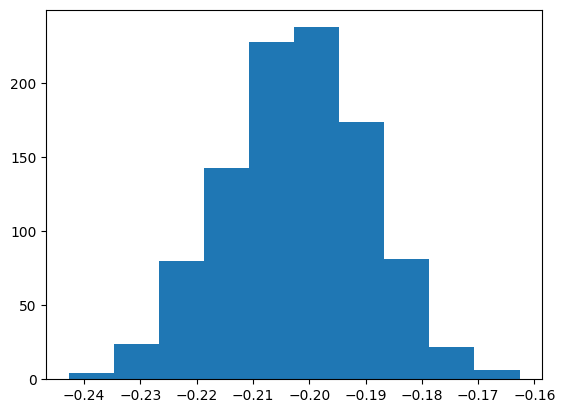

In [3]:
## 3.2
# input data
Y_m = exercise_3_2()

plt.hist(Y_m)

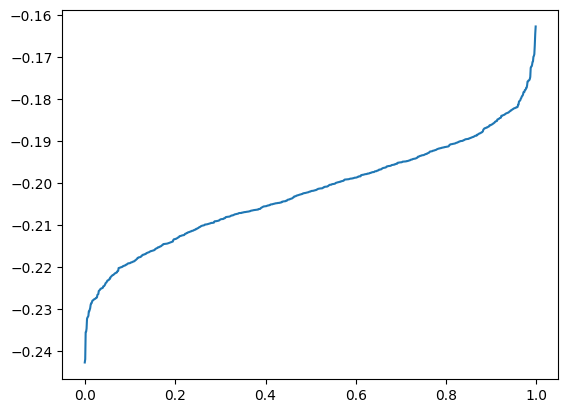

In [4]:
## 3.3
Y_m.sort()
C_m = [(m-0.5)/1000 for m in range(len(Y_m))]
plt.plot(C_m, Y_m)

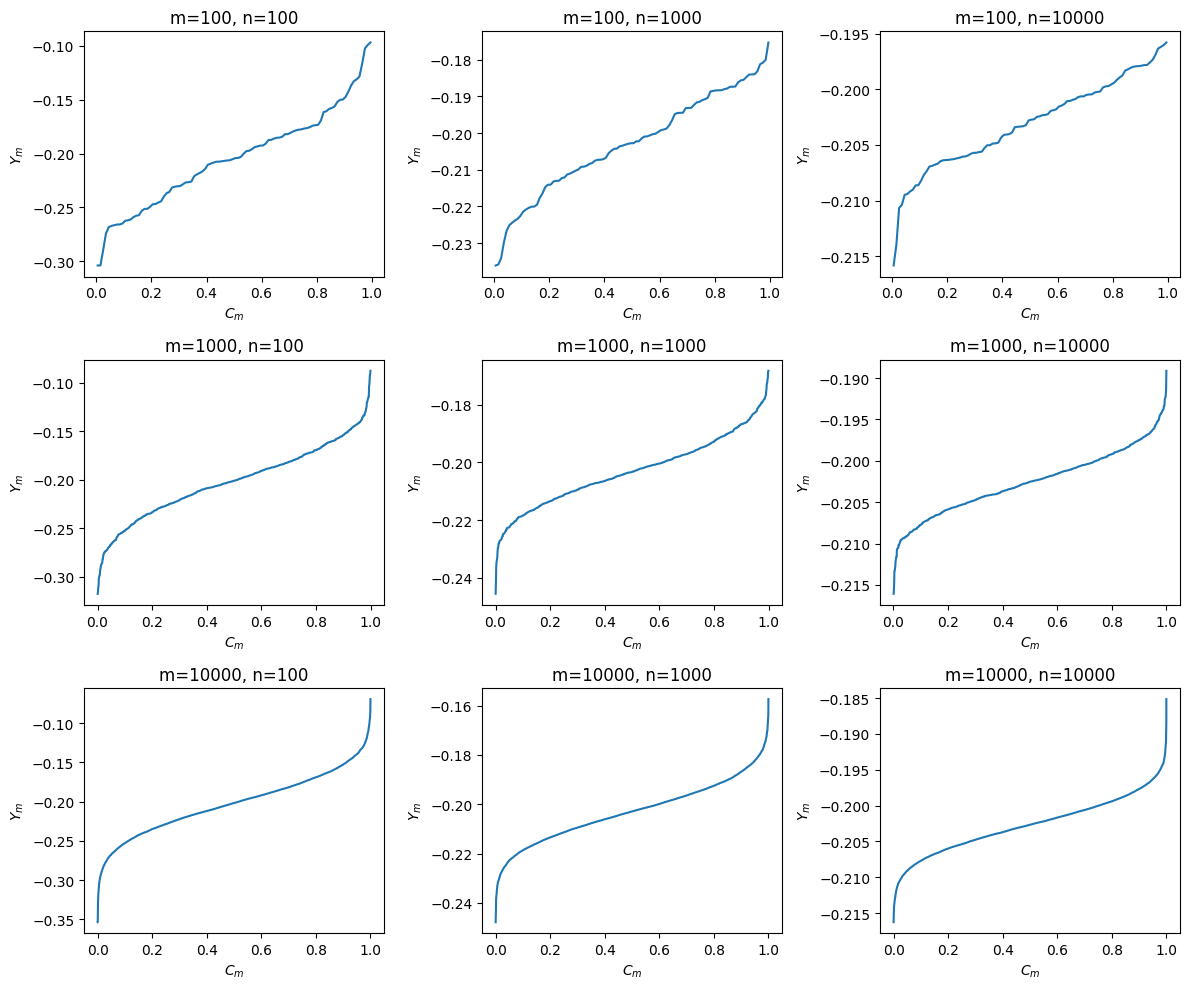

In [5]:
m_vals = [100, 1000, 10000]
n_vals = [100, 1000, 10000]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i, m in enumerate(m_vals):
    C_m_test = [(k - 0.5)/m for k in range(1, m+1)]
    for j, n in enumerate(n_vals):
        Y_m_test = exercise_3_2(m=m, n=n)
        Y_m_test.sort()

        ax = axes[i, j]
        ax.plot(C_m_test, Y_m_test)
        ax.set_title(f"m={m}, n={n}")
        ax.set_xlabel("$C_m$")
        ax.set_ylabel("$Y_m$")

plt.tight_layout()
plt.show()


In [ ]:
### 3.4 
def exercise_3_4(m=10**6, n=1, step_n = 1_000):
    U = rng.uniform(size=(m, n))
    f_u = f_ex_3(U)
    y_m_list, std_list  = [], []
    N_val = range(step_n, m, step_n)
    for i in N_val:
        mc_european_list.append(np.mean(f_u[:i,:]))
        std_list.append(np.std(f_u[:i,:], ddof=1)/ np.sqrt(i))
        
    return np.array(mc_european_list), np.array(std_list), np.array(list(N_val))

step_n = 1_000
mc_european_list, std_list, N_val  = exercise_3_4(step_n = step_n)


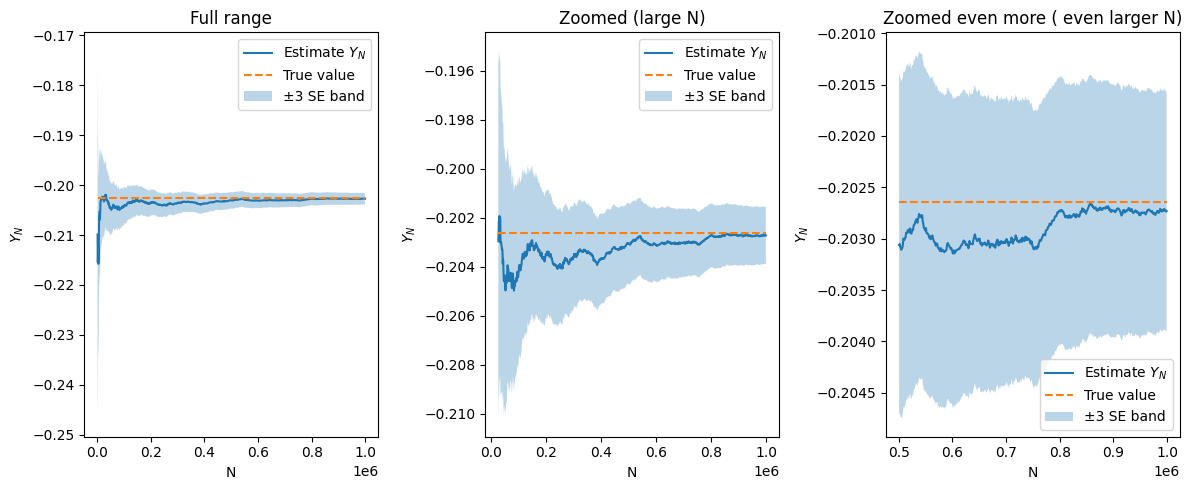

In [ ]:
upper = y_m_list + 3 * std_list
lower = mc_european_list - 3 * std_list

target_array = -2/np.pi**2*np.ones_like(y_m_list)

fig, ax = plt.subplots(1, 3, figsize=(12,5))

ax[0].plot(N_val, y_m_list, label="Estimate $Y_N$")
ax[0].plot(N_val, target_array, linestyle='--', label="True value")
ax[0].fill_between(N_val, lower, upper, alpha=0.3, label="±3 SE band")

ax[0].set_xlabel("N")
ax[0].set_ylabel("$Y_N$")
ax[0].set_title("Full range")
ax[0].legend()

BEGIN = 25
ax[1].plot(N_val[BEGIN:], y_m_list[BEGIN:], label="Estimate $Y_N$")
ax[1].plot(N_val[BEGIN:], target_array[BEGIN:], linestyle='--', label="True value")
ax[1].fill_between(N_val[BEGIN:], lower[BEGIN:], upper[BEGIN:], alpha=0.3, label="±3 SE band")

ax[1].set_xlabel("N")
ax[1].set_ylabel("$Y_N$")
ax[1].set_title("Zoomed (large N)")
ax[1].legend()

BEGIN = 500
ax[2].plot(N_val[BEGIN:], y_m_list[BEGIN:], label="Estimate $Y_N$")
ax[2].plot(N_val[BEGIN:], target_array[BEGIN:], linestyle='--', label="True value")
ax[2].fill_between(N_val[BEGIN:], lower[BEGIN:], upper[BEGIN:], alpha=0.3, label="±3 SE band")

ax[2].set_xlabel("N")
ax[2].set_ylabel("$Y_N$")
ax[2].set_title("Zoomed even more ( even larger N)")
ax[2].legend()

plt.tight_layout()
plt.show()


### 3.5

In [9]:
import numpy as np

from numpy       import pi, sqrt, log, exp
from scipy.stats import norm

#
# Normal cumulative distribution function, with extension
# for complex argument with small imaginary component
#

def norm_cdf(x):
    if not isinstance(x, np.ndarray):
        xr = x.real
        xi = x.imag
        if abs(xi) > 1.0e-10:
            raise ValueError('imag(x) too large in norm_cdf(x)')

        ncf = norm.cdf(xr)
        if abs(xi) > 0:
            ncf = ncf + 1.0j*xi*norm.pdf(xr)
    else:
        xr = np.real(x)
        xi = np.imag(x)
        if any(abs(xi) > 1.0e-10):
            raise ValueError('imag(x) too large in norm_cdf(x)')

        ncf = norm.cdf(xr)
        if any(abs(xi) > 0):
            ncf = ncf + 1.0j*xi*norm.pdf(xr)

    return ncf

# V = european_call(r,sigma,T,S,K,opt)
#
# Black-Scholes European call option solution
# as defined in equation (3.17) on page 48 of
# The Mathematics of Financial Derivatives
# by Wilmott, Howison and Dewynne
#
# r     - interest rate
# sigma - volatility
# T     - time interval
# S     - asset value(s)  (float or flattened numpy array)
# K     - strike price(s) (float or flattened numpy array)
# opt   - 'value', 'delta', 'gamma' or 'vega'
# V     - option value(s) (float or flattened numpy array)
#

def european_call(r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value'):

    S  = S + 1.0e-100     # avoids problems with S=0
    K  = K + 1.0e-100     # avoids problems with K=0

    d1 = ( log(S) - log(K) + (r+0.5*sigma**2)*T ) / (sigma*sqrt(T))
    d2 = ( log(S) - log(K) + (r-0.5*sigma**2)*T ) / (sigma*sqrt(T))

    if opt == 'value':
        V = S*norm_cdf(d1) - exp(-r*T)*K*norm_cdf(d2)
    elif opt == 'delta':
        V = norm_cdf(d1)
    elif opt == 'gamma':
        V = exp(-0.5*d1**2) / (sigma*sqrt(2*pi*T)*S)
    elif opt == 'vega':
        V =             S*(exp(-0.5*d1**2)/sqrt(2*pi))*( sqrt(T)-d1/sigma) \
            - exp(-r*T)*K*(exp(-0.5*d2**2)/sqrt(2*pi))*(-sqrt(T)-d2/sigma)

    else:
        raise ValueError('invalid value for opt -- must be "value", "delta", "gamma", "vega"')

    return V

In [11]:
import scipy

In [38]:
m,n = 1000, 1000
r=0.05
sigma=0.2
T=1
S=100
K=100
opt='value'

def f_for_european(W, r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value'):
    S_T = S* np.exp((r-0.5*sigma**2)*T+sigma*W)

    return np.exp(-r*T)*np.maximum(S_T-K,0)

def mc_mean_var_3_5(sim_european):
    return np.mean(sim_european,axis=0), np.std(sim_european, ddof=1, axis=0)


U = rng.uniform(size=(m, n))
X = scipy.stats.norm.ppf(U)
W = np.sqrt(T)*X
true_european = european_call(r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value')
sim_european = f_for_european(W)
mc_euro_mean, mc_euro_std = mc_mean_var_3_5(sim_european)


(array([ 10.,  23.,  72., 155., 258., 237., 137.,  68.,  31.,   9.]),
 array([ 9.01224889,  9.29900268,  9.58575646,  9.87251025, 10.15926404,
        10.44601782, 10.73277161, 11.0195254 , 11.30627918, 11.59303297,
        11.87978676]),
 <BarContainer object of 10 artists>)

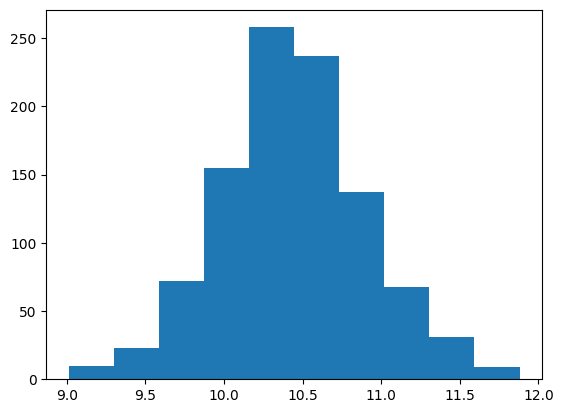

In [41]:
plt.hist(mc_euro_mean)

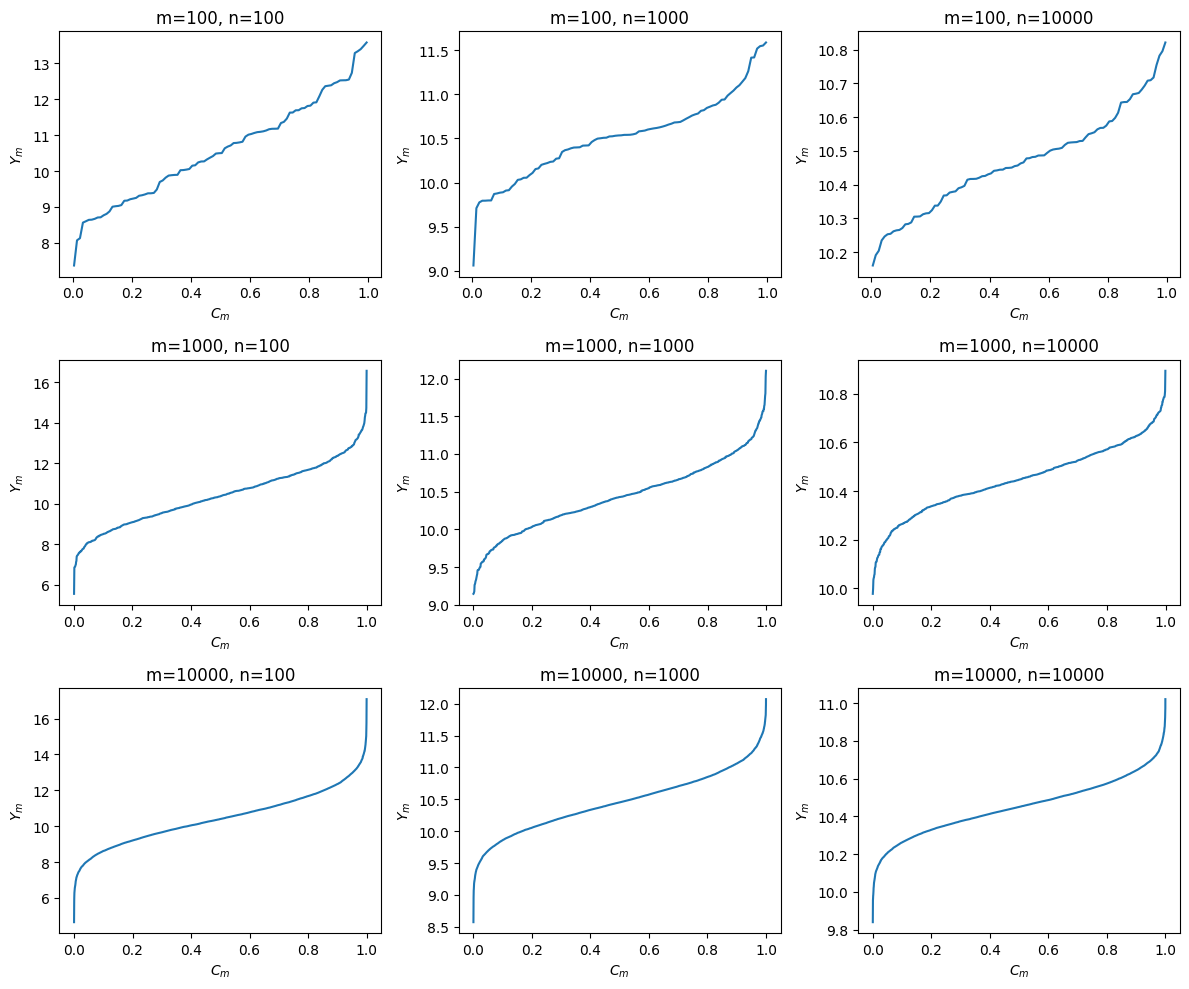

In [48]:
# 3.5.3
m_vals = [100, 1000, 10000]
n_vals = [100, 1000, 10000]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i, m in enumerate(m_vals):
    C_m_test = [(k - 0.5)/m for k in range(1, m+1)]
    for j, n in enumerate(n_vals):
        U = rng.uniform(size=(n, m))
        X = scipy.stats.norm.ppf(U)
        W = np.sqrt(T)*X
        true_european = european_call(r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value')
        sim_european = f_for_european(W)
        mc_euro_mean, mc_euro_std = mc_mean_var_3_5(sim_european)

        mc_euro_mean.sort()

        ax = axes[i, j]
        ax.plot(C_m_test, mc_euro_mean)
        ax.set_title(f"m={m}, n={n}")
        ax.set_xlabel("$C_m$")
        ax.set_ylabel("$Y_m$")

plt.tight_layout()
plt.show()


In [49]:
# 3.5.4
### 3.4 
def exercise_3_5_4(m=10**6, n=1, step_n = 1_000):
    U = rng.uniform(size=(n, m))
    X = scipy.stats.norm.ppf(U)
    W = np.sqrt(T)*X
    sim_european = f_for_european(W)
    
    mc_european_list, std_euro_list  = [], []
    N_euro_val = range(step_n, m, step_n)
    for i in N_euro_val:
        mc_european_list.append(np.mean(sim_european[:i,:]))
        std_euro_list.append(np.std(sim_european[:i,:], ddof=1)/ np.sqrt(i))
        
    return np.array(mc_european_list), np.array(std_euro_list), np.array(list(N_euro_val))

step_n = 1_000
mc_european_list, std_euro_list, N_euro_val  = exercise_3_4(step_n = step_n)


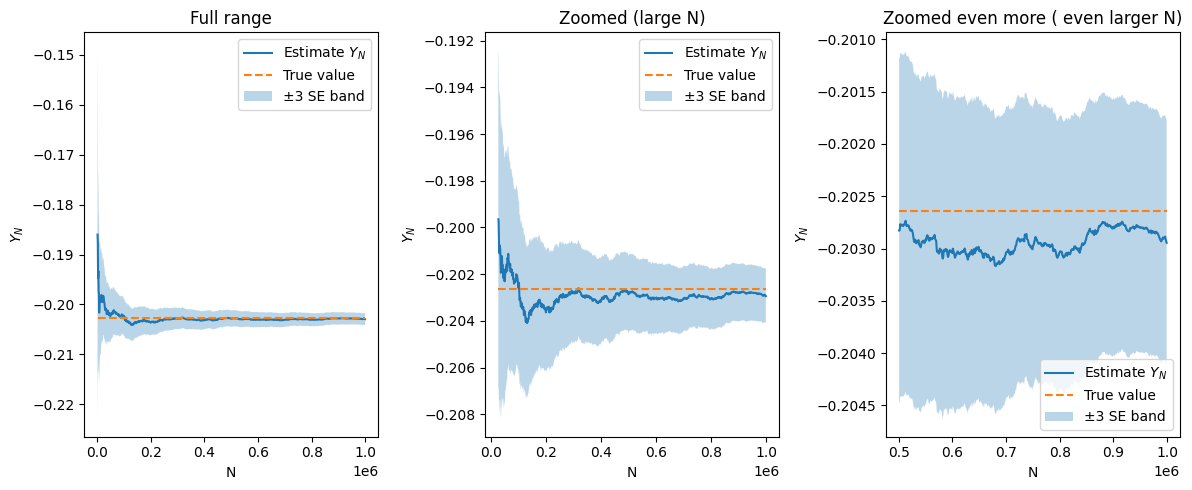

In [50]:
upper = mc_european_list + 3 * std_euro_list
lower = mc_european_list - 3 * std_euro_list

target_array = -2/np.pi**2*np.ones_like(mc_european_list)

fig, ax = plt.subplots(1, 3, figsize=(12,5))

ax[0].plot(N_euro_val, mc_european_list, label="Estimate $Y_N$")
ax[0].plot(N_euro_val, target_array, linestyle='--', label="True value")
ax[0].fill_between(N_euro_val, lower, upper, alpha=0.3, label="±3 SE band")

ax[0].set_xlabel("N")
ax[0].set_ylabel("$Y_N$")
ax[0].set_title("Full range")
ax[0].legend()

BEGIN = 25
ax[1].plot(N_euro_val[BEGIN:], mc_european_list[BEGIN:], label="Estimate $Y_N$")
ax[1].plot(N_euro_val[BEGIN:], target_array[BEGIN:], linestyle='--', label="True value")
ax[1].fill_between(N_euro_val[BEGIN:], lower[BEGIN:], upper[BEGIN:], alpha=0.3, label="±3 SE band")

ax[1].set_xlabel("N")
ax[1].set_ylabel("$Y_N$")
ax[1].set_title("Zoomed (large N)")
ax[1].legend()

BEGIN = 500
ax[2].plot(N_euro_val[BEGIN:], mc_european_list[BEGIN:], label="Estimate $Y_N$")
ax[2].plot(N_euro_val[BEGIN:], target_array[BEGIN:], linestyle='--', label="True value")
ax[2].fill_between(N_euro_val[BEGIN:], lower[BEGIN:], upper[BEGIN:], alpha=0.3, label="±3 SE band")

ax[2].set_xlabel("N")
ax[2].set_ylabel("$Y_N$")
ax[2].set_title("Zoomed even more ( even larger N)")
ax[2].legend()

plt.tight_layout()
plt.show()
